# 02 — Демонстрация пяти методов интерполяции

Ноутбук визуально демонстрирует работу пяти методов интерполяции на реальном фрагменте парусного трека и иллюстрирует характерные особенности каждого метода, включая осцилляции Рунге у полинома Лагранжа.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from interp_research.plotting import THESIS_COLORS, set_thesis_style
from interp_research.methods import linear, lagrange, cubic_spline, b_spline, motion_aware

set_thesis_style()

In [2]:
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRACK_FILE = "gin-sul-rund-hanskalbsand-2024-yury__Gin_Sul_Rund_Hanskalbsand_2024.npz"
DECIMATE_STEP = 5
FRAGMENT_START = 856
FRAGMENT_END = 936

## Загрузка трека

Берём фрагмент трека регаты Gin Sul Rund Hanskalbsand 2024 — участок с активной лавировкой (~450 с, 80 точек при средней частоте записи ~5.4 с).

In [3]:
data = np.load(PROCESSED_DIR / TRACK_FILE)
t_full = data["t"][FRAGMENT_START:FRAGMENT_END]
x_full = data["x_local"][FRAGMENT_START:FRAGMENT_END]
y_full = data["y_local"][FRAGMENT_START:FRAGMENT_END]

t_full = t_full - t_full[0]

print(f"Фрагмент: {len(t_full)} точек, {t_full[-1]:.0f} секунд")
print(f"Средний Δt: {np.mean(np.diff(t_full)):.1f} с")

Фрагмент: 80 точек, 453 секунд
Средний Δt: 5.7 с


## Прореживание трека

Прорежаем трек: оставляем каждую 5-ю точку как **известные узлы** (known) — это входные данные для всех методов интерполяции. Остальные точки становятся **удержанной выборкой** (held-out) — это реальные GPS-позиции, которые мы «прячем» от алгоритмов, чтобы потом сравнить восстановленную кривую с тем, где яхта действительно находилась.

In [4]:
known_mask = np.zeros(len(t_full), dtype=bool)
known_mask[::DECIMATE_STEP] = True

t_known = t_full[known_mask]
x_known = x_full[known_mask]
y_known = y_full[known_mask]

held_mask = ~known_mask
t_held = t_full[held_mask]
x_held = x_full[held_mask]
y_held = y_full[held_mask]

print(f"Узлов (known): {known_mask.sum()}, удержано (held-out): {held_mask.sum()}")

Узлов (known): 16, удержано (held-out): 64


## Прогон пяти методов интерполяции

Для каждого метода интерполируем координаты $x(t)$ и $y(t)$ в плотную сетку из 1000 точек.

In [5]:
t_dense = np.linspace(t_known[0], t_known[-1], 1000)

methods = {
    "Линейная": linear.interpolate,
    "Лагранж (degree=8)": lambda t_k, x_k, t_q: lagrange.interpolate(t_k, x_k, t_q, degree=8),
    "Кубический сплайн": cubic_spline.interpolate,
    "B-сплайн": b_spline.interpolate,
    "Motion-aware": motion_aware.interpolate,
}

results = {}
for name, method in methods.items():
    x_interp = method(t_known, x_known, t_dense)
    y_interp = method(t_known, y_known, t_dense)
    results[name] = (x_interp, y_interp)

print(f"Интерполяция выполнена: {len(results)} методов × 1000 точек")

Интерполяция выполнена: 5 методов × 1000 точек


## Рисунок 3 ВКР — сравнение пяти методов интерполяции

Вместо показа всей траектории целиком (на которой кривые сливаются) увеличиваем два характерных участка — повороты на $t \approx 39$ с (смена курса на 79°) и $t \approx 361$ с (смена курса на 74°). Именно на поворотах различия между методами максимальны.

Сохранено: ../results/figures/fig_03_methods_comparison.png


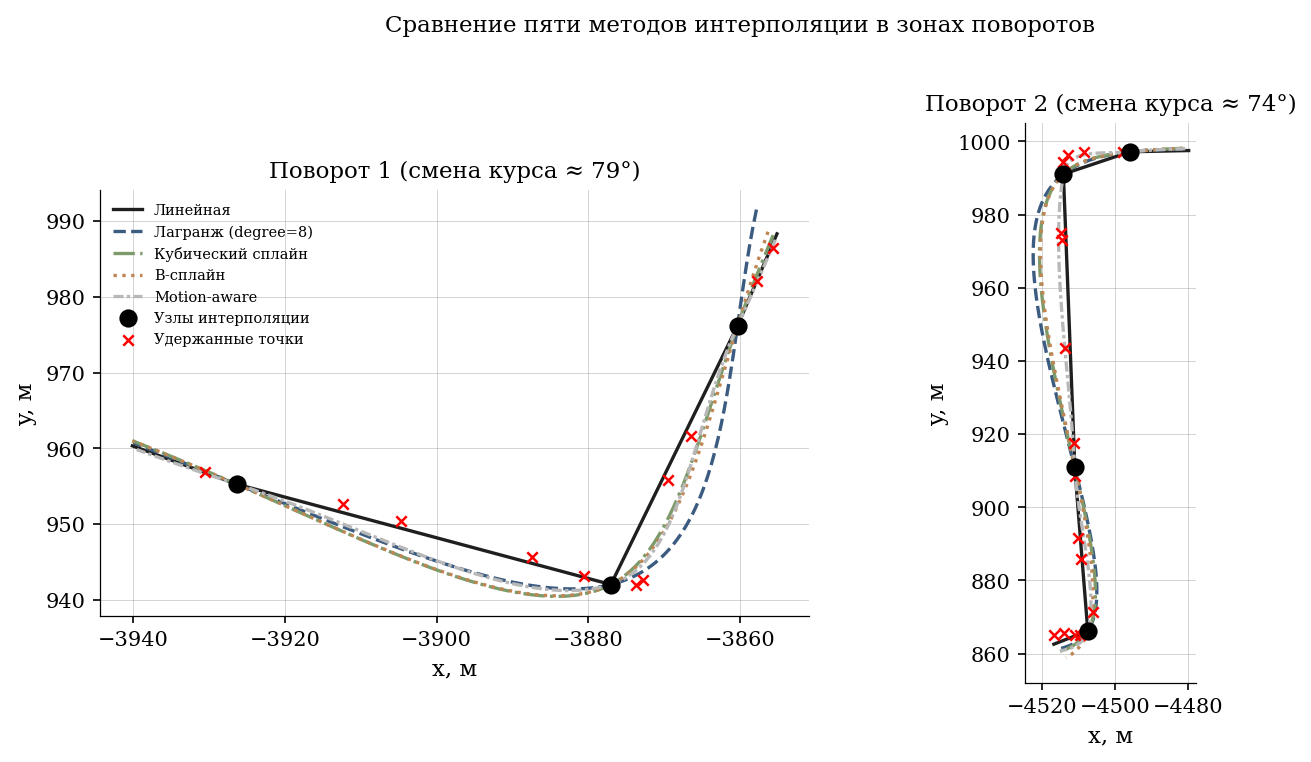

In [6]:
line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

# Два участка: поворот 1 (t≈16..68) и поворот 2 (t≈348..422)
zones = [
    {"t_range": (10, 75), "title": "Поворот 1 (смена курса ≈ 79°)"},
    {"t_range": (340, 430), "title": "Поворот 2 (смена курса ≈ 74°)"},
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, zone in zip(axes, zones):
    t_lo, t_hi = zone["t_range"]
    mask_dense = (t_dense >= t_lo) & (t_dense <= t_hi)
    mask_known = (t_known >= t_lo) & (t_known <= t_hi)
    mask_held = (t_held >= t_lo) & (t_held <= t_hi)

    for i, (name, (xi, yi)) in enumerate(results.items()):
        ax.plot(xi[mask_dense], yi[mask_dense],
                linestyle=line_styles[i], color=THESIS_COLORS[i],
                linewidth=1.6, label=name, zorder=2 + i)

    ax.scatter(x_known[mask_known], y_known[mask_known],
               s=60, c="black", marker="o", zorder=10, label="Узлы интерполяции")
    ax.scatter(x_held[mask_held], y_held[mask_held],
               s=25, c="red", marker="x", linewidths=1.2,
               zorder=9, label="Удержанные точки")

    ax.set_xlabel("x, м")
    ax.set_ylabel("y, м")
    ax.set_title(zone["title"])
    ax.set_aspect("equal")

axes[0].legend(fontsize=7, loc="best")

fig.suptitle("Сравнение пяти методов интерполяции в зонах поворотов", fontsize=11, y=1.01)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "fig_03_methods_comparison.png", dpi=300)
print(f"Сохранено: {FIGURES_DIR / 'fig_03_methods_comparison.png'}")
plt.show()

### Наблюдения

- **Линейная интерполяция** даёт характерные «изломы» в узлах — траектория выглядит как ломаная. В зонах поворотов кривая срезает дугу, не дотягиваясь до удержанных точек.
- **Полином Лагранжа** (степень 8) на поворотах отклоняется от реальной траектории сильнее других методов — видны выбросы кривой в сторону от удержанных точек. Это следствие глобального характера полинома высокой степени.
- **Кубический сплайн** и **B-сплайн** дают визуально схожие гладкие кривые. Различия между ними минимальны и проявляются на краях фрагмента (разные граничные условия: natural vs not-a-knot).
- **Motion-aware** (эрмитова интерполяция) учитывает направление движения в узлах. На крутых поворотах это даёт более реалистичную траекторию, лучше согласованную с удержанными точками.

## Иллюстрация осцилляций Рунге

Берём короткий участок (~20 секунд) и показываем крупным планом поведение полинома Лагранжа степени 8 — нефизичные колебания между крайними узлами скользящего окна.

Сохранено: ../results/figures/fig_runge_oscillations.png


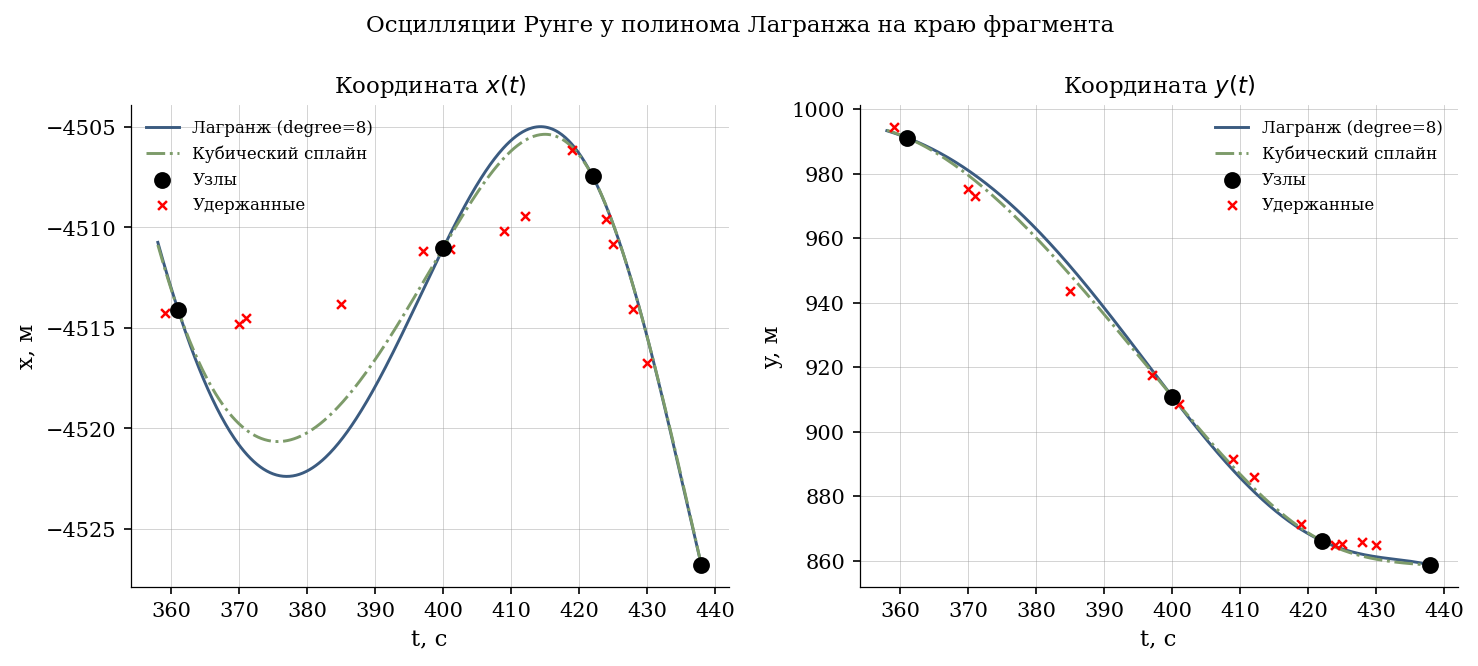

In [7]:
# Участок ~20 секунд вблизи края фрагмента, где осцилляции Рунге наиболее выражены
runge_duration = 80
t_runge_end = t_known[-1]
t_runge_start = t_runge_end - runge_duration

t_runge = np.linspace(t_runge_start, t_runge_end, 500)
x_lag_runge = lagrange.interpolate(t_known, x_known, t_runge, degree=8)
y_lag_runge = lagrange.interpolate(t_known, y_known, t_runge, degree=8)
x_cs_runge = cubic_spline.interpolate(t_known, x_known, t_runge)
y_cs_runge = cubic_spline.interpolate(t_known, y_known, t_runge)

runge_known_mask = (t_known >= t_runge_start) & (t_known <= t_runge_end)
runge_held_mask = (t_held >= t_runge_start) & (t_held <= t_runge_end)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

ax1 = axes[0]
ax1.plot(t_runge, x_lag_runge, color=THESIS_COLORS[1], linewidth=1.4,
         label="Лагранж (degree=8)")
ax1.plot(t_runge, x_cs_runge, color=THESIS_COLORS[2], linewidth=1.4,
         linestyle="-.", label="Кубический сплайн")
ax1.scatter(t_known[runge_known_mask], x_known[runge_known_mask],
            s=50, c="black", marker="o", zorder=10, label="Узлы")
ax1.scatter(t_held[runge_held_mask], x_held[runge_held_mask],
            s=18, c="red", marker="x", zorder=9, label="Удержанные")
ax1.set_xlabel("t, с")
ax1.set_ylabel("x, м")
ax1.set_title("Координата $x(t)$")
ax1.legend(fontsize=8)

ax2 = axes[1]
ax2.plot(t_runge, y_lag_runge, color=THESIS_COLORS[1], linewidth=1.4,
         label="Лагранж (degree=8)")
ax2.plot(t_runge, y_cs_runge, color=THESIS_COLORS[2], linewidth=1.4,
         linestyle="-.", label="Кубический сплайн")
ax2.scatter(t_known[runge_known_mask], y_known[runge_known_mask],
            s=50, c="black", marker="o", zorder=10, label="Узлы")
ax2.scatter(t_held[runge_held_mask], y_held[runge_held_mask],
            s=18, c="red", marker="x", zorder=9, label="Удержанные")
ax2.set_xlabel("t, с")
ax2.set_ylabel("y, м")
ax2.set_title("Координата $y(t)$")
ax2.legend(fontsize=8)

fig.suptitle("Осцилляции Рунге у полинома Лагранжа на краю фрагмента", fontsize=11)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "fig_runge_oscillations.png", dpi=300)
print(f"Сохранено: {FIGURES_DIR / 'fig_runge_oscillations.png'}")
plt.show()

Полученное поведение является классическим проявлением осцилляций Рунге, теоретически описанным в разделе 1.3 ВКР. Полином Лагранжа высокой степени, интерполирующий данные на равномерной сетке, демонстрирует нарастающие колебания вблизи краёв интервала — чем выше степень, тем сильнее осцилляции. Кубический сплайн, напротив, свободен от этого эффекта благодаря кусочной структуре.

## Итог

В этом ноутбуке получены рисунки 3 и иллюстрация осцилляций Рунге. Количественное сравнение методов проводится в ноутбуке 03.